# Simulación de Datos Operativos: Puku Puku Café
**Autor:** Fabricio Chavez Ccorahua  
**Objetivo:** Generar un dataset sintético basado en distribuciones de probabilidad (Poisson y Log-Normal) para analizar el comportamiento operativo y comercial de Puku Puku Café.

In [2]:
import numpy as np
import pandas as pd
import random
from datetime import datetime, timedelta

# Semillas
np.random.seed(42)
random.seed(42)

print(" Librerías cargadas correctamente.")

 Librerías cargadas correctamente.


In [3]:
def crear_catalogos():
    "crea tablas de sucursales y productos"
    #Sucursales
    sucursales = pd.DataFrame([
        {"sucursal_id": "SUC-01", "nombre": "Puku Puku Miraflores"},
        {"sucursal_id": "SUC-02", "nombre": "Puku Puku San Isidro"},
        {"sucursal_id": "SUC-03", "nombre": "Puku Puku Surco"}
    ])

    #Productos
    productos = pd.DataFrame([
        {"producto_id": "PROD-01", "nombre": "Espresso Doble", "precio": 9.50},
        {"producto_id": "PROD-02", "nombre": "Capuccino 12oz", "precio": 13.00},
        {"producto_id": "PROD-03", "nombre": "Cold Brew", "precio": 15.00},
        {"producto_id": "PROD-04", "nombre": "sandwich de Pavo", "precio": 22.00}
    ])

    return sucursales, productos

df_sucursales, df_productos = crear_catalogos()
df_productos

,producto_id,nombre,precio
0,PROD-01,Espresso Doble,9.5
1,PROD-02,Capuccino 12oz,13.0
2,PROD-03,Cold Brew,15.0
3,PROD-04,sandwich de Pavo,22.0


In [4]:
def clientes_segun_hora(hora):
    "Aplica distribucion de Poisson para modelar llegadas."
    "Retorna numero de clientes esperados segun horario."
    if hora in [8,9,16,17]: #Horas punta
        return np.random.poisson(lam=45)
    else:
        return np.random.poisson(lam=15)

print(f"Clientes simulados a las 8:00 AM (Hora Punta):{clientes_segun_hora(8)}")
print(f"Clientes simulados a las 2:00 AM (Hora Valle):{clientes_segun_hora(14)}")

Clientes simulados a las 8:00 AM (Hora Punta):42
Clientes simulados a las 2:00 AM (Hora Valle):18


In [5]:
def simular_ventas(df_sucursales,df_productos,dias_a_simular=30):
    "Genera ventas durante el periodo indicado"

    lista_compras = []
    fecha_inicio = datetime(2026,3,1)

    for dia in range(dias_a_simular):
        fecha_actual = fecha_inicio + timedelta(days=dia)

        for _, sucursal in df_sucursales.iterrows():
            #Atendemos de 7 AM a 8 PM (7 a 20)
            for hora in range(7,21):

                total_clientes = clientes_segun_hora(hora)

                for _ in range (total_clientes):
                    minuto = random.randint(0,59)
                    segundo = random.randint(0,59)
                    momento_compra = fecha_actual.replace(hour=hora, minute=minuto, second=segundo)

                    #Seleccion aleatoria de producto
                    producto = df_productos.sample(1).iloc[0]

                    #Gasto (Log-Normal) y Tiempo de atencion (Log-Normal)
                    monto_gasto = float(np.random.lognormal(mean=2.8,sigma=0.4))
                    tiempo_atencion = float(np.random.lognormal(mean=1.1, sigma=0.3))

                    lista_compras.append({
                        "fecha_hora": momento_compra,
                        "sucursal_id": sucursal["sucursal_id"],
                        "producto_id": producto["producto_id"],
                        "monto_total": round(monto_gasto,2),
                        "tiempo_atencion_min": round(tiempo_atencion, 2)
                    })

    df = pd.DataFrame(lista_compras)

    #ordenar
    df = df.sort_values(by="fecha_hora").reset_index(drop=True)

    #asignar transaccion_id en secuencia tras ordenar
    df["transaccion_id"] = [f"TXN-{i+1:06d}" for i in range(len(df))]

    columnas_ordenadas = [
        "transaccion_id",
        "fecha_hora",
        "sucursal_id",
        "producto_id",
        "monto_total",
        "tiempo_atencion_min"
    ]

    df = df[columnas_ordenadas]

    return df

df_ventas = simular_ventas(df_sucursales,df_productos,dias_a_simular=30)
print(f"Simulacion completada, se generaron {len(df_ventas):,} registros.")

Simulacion completada, se generaron 29,822 registros.


In [6]:
# Muestra de las primeras 5 ventas
print("Muestra de transacciones generadas:")
display(df_ventas.head())

print("\n Resumen de Métricas Simuladas:")
print(f"• Total de Ventas: S/. {df_ventas['monto_total'].sum():,.2f}")
print(f"• Ticket Promedio: S/. {df_ventas['monto_total'].mean():.2f}")
print(f"• Tiempo Promedio de Atención: {df_ventas['tiempo_atencion_min'].mean():.2f} min")

Muestra de transacciones generadas:


,transaccion_id,fecha_hora,sucursal_id,producto_id,monto_total,tiempo_atencion_min
0,TXN-000001,2026-03-01 07:01:05,SUC-01,PROD-01,18.71,1.98
1,TXN-000002,2026-03-01 07:01:07,SUC-02,PROD-03,15.78,2.98
2,TXN-000003,2026-03-01 07:01:47,SUC-01,PROD-04,13.04,2.57
3,TXN-000004,2026-03-01 07:02:56,SUC-03,PROD-02,19.58,3.39
4,TXN-000005,2026-03-01 07:05:14,SUC-03,PROD-03,13.03,2.52



 Resumen de Métricas Simuladas:
• Total de Ventas: S/. 532,037.53
• Ticket Promedio: S/. 17.84
• Tiempo Promedio de Atención: 3.14 min


In [7]:
df_ventas.to_csv("fact_ventas.csv", index=False)
df_sucursales.to_csv("dim_sucursales.csv", index=False)
df_productos.to_csv("dim_productos.csv", index=False)

print("hecho")

hecho


In [8]:
# Celda 8 [gráficos]
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración gráficos modernos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


C:\Users\nofab\AppData\Local\Temp\ipykernel_6376\1207738246.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


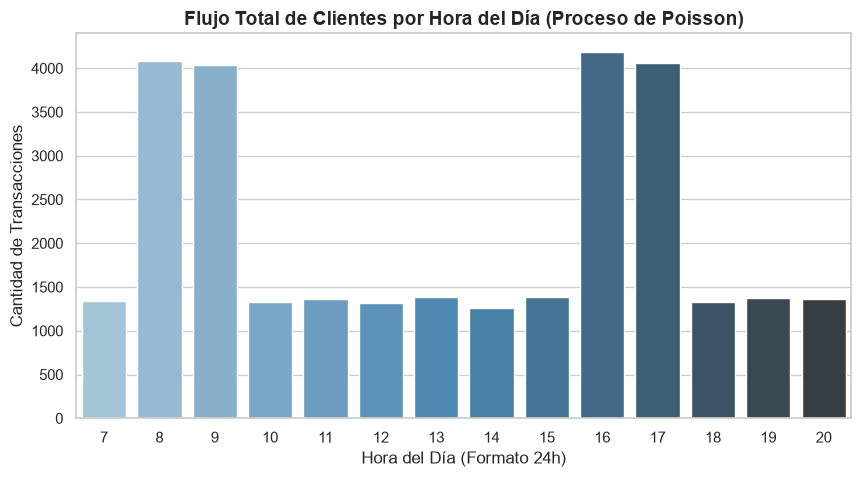

In [9]:
#Celda 9 [grafico flujo de clientes por hora]

#nueva columna temporal
df_ventas["hora"] = df_ventas["fecha_hora"].dt.hour

#figura
plt.figure(figsize=(10,5))

#gráfico de barras con Seaborn
ax = sns.countplot(
    data=df_ventas,
    x="hora",
    palette="Blues_d"
)

#Títulos y etiquetas
plt.title("Flujo Total de Clientes por Hora del Día (Proceso de Poisson)", fontsize=14, fontweight="bold")
plt.xlabel("Hora del Día (Formato 24h)", fontsize=12)
plt.ylabel("Cantidad de Transacciones", fontsize=12)

#Mostrar gráfico
plt.show()

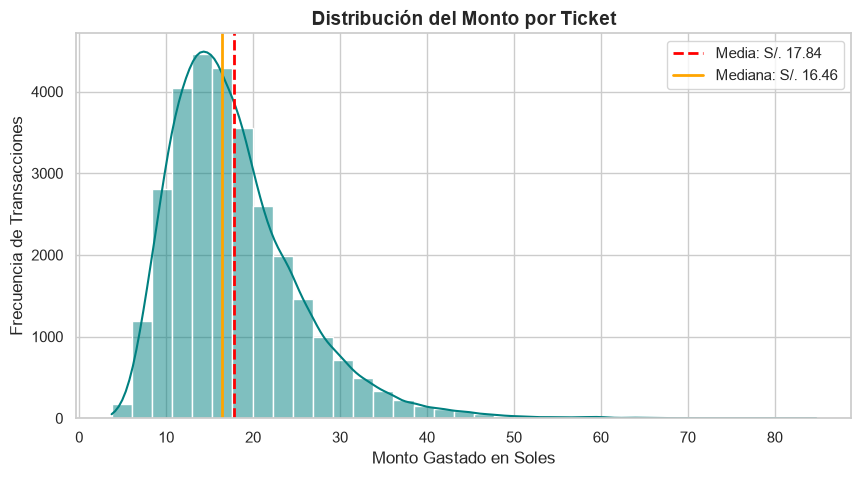

In [ ]:
#Celda 10 [Gráfico distribución de montos por ticket (Log-Normal)]

plt.figure(figsize=(10,5))

#histograma con curva densidad (KDE)
sns.histplot(
    data=df_ventas,
    x="monto_total",
    kde=True,
    color="teal",
    bins=35
)

#media y mediana
media = df_ventas["monto_total"].mean()
mediana = df_ventas["monto_total"].median()

plt.axvline(media,color="red",linestyle="--",linewidth=2,label=f"Media: S/. {media:.2f}")
plt.axvline(mediana,color="orange",linestyle="-",linewidth=2,label=f"Mediana: S/. {mediana:.2f}")

#titulos y leyendas
plt.title("Distribución del Monto por Ticket",fontsize=14,fontweight="bold")
plt.xlabel("Monto Gastado en Soles",fontsize=12)
plt.ylabel("Frecuencia de Transacciones",fontsize=12)
plt.legend(fontsize=11)

plt.show()